<a href="https://colab.research.google.com/github/Ashutos0762/Reservoir_MBE_Solvers/blob/main/MBE_project_case3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Case 3: Gas-Cap Drive Reservoir (Tarek Ahmed, Example 11-4)
# MBE: F = N*Eo + N*m*Eg → Plot F/Eo vs Eg/Eo to find N and m

Rsi = 975
Bti = 1.6291
Bgi = 0.00077

data = pd.DataFrame({
    'P':  [4415, 3875, 3315, 2845],
    'Np': [0, 492.5, 1015.7, 1322.5],
    'Gp': [0, 751.3, 2409.6, 3901.6],
    'Bt': [1.6291, 1.6839, 1.7835, 1.9110],
    'Bg': [0.00077, 0.00079, 0.00087, 0.00099]
})
data

,P,Np,Gp,Bt,Bg
0,4415,0.0,0.0,1.6291,0.00077
1,3875,492.5,751.3,1.6839,0.00079
2,3315,1015.7,2409.6,1.7835,0.00087
3,2845,1322.5,3901.6,1.9110,0.00099


In [ ]:
mask = data['Np'] > 0

# Rp (scf/STB) = Gp(MMscf → scf) / Np(MSTB → STB)
data.loc[mask, 'Rp'] = (data.loc[mask, 'Gp'] * 1e6) / (data.loc[mask, 'Np'] * 1e3)

# F (bbl) = Np*Bt + (Gp - Np*Rsi)*Bg  [converting to base units]
Np_stb = data.loc[mask, 'Np'] * 1e3
Gp_scf = data.loc[mask, 'Gp'] * 1e6
data.loc[mask, 'F'] = Np_stb * data.loc[mask, 'Bt'] + (Gp_scf - Np_stb * Rsi) * data.loc[mask, 'Bg']

# Eo = Bt - Bti
data.loc[mask, 'Eo'] = data.loc[mask, 'Bt'] - Bti

# Eg = Boi * (Bg/Bgi - 1)
data.loc[mask, 'Eg'] = Bti * (data.loc[mask, 'Bg'] / Bgi - 1)

data.loc[mask, 'F/Eo'] = data.loc[mask, 'F'] / data.loc[mask, 'Eo']
data.loc[mask, 'Eg/Eo'] = data.loc[mask, 'Eg'] / data.loc[mask, 'Eo']

data[mask][['P', 'Rp', 'F', 'Eo', 'Eg', 'F/Eo', 'Eg/Eo']].round(4)

,P,Rp,F,Eo,Eg,F/Eo,Eg/Eo
1,3875,1525.4822,1043499.625,0.0548,0.0423,1.904196e+07,0.7722
2,3315,2372.3540,3046285.425,0.1544,0.2116,1.972983e+07,1.3703
3,2845,2950.1701,5113338.375,0.2819,0.4655,1.813884e+07,1.6511


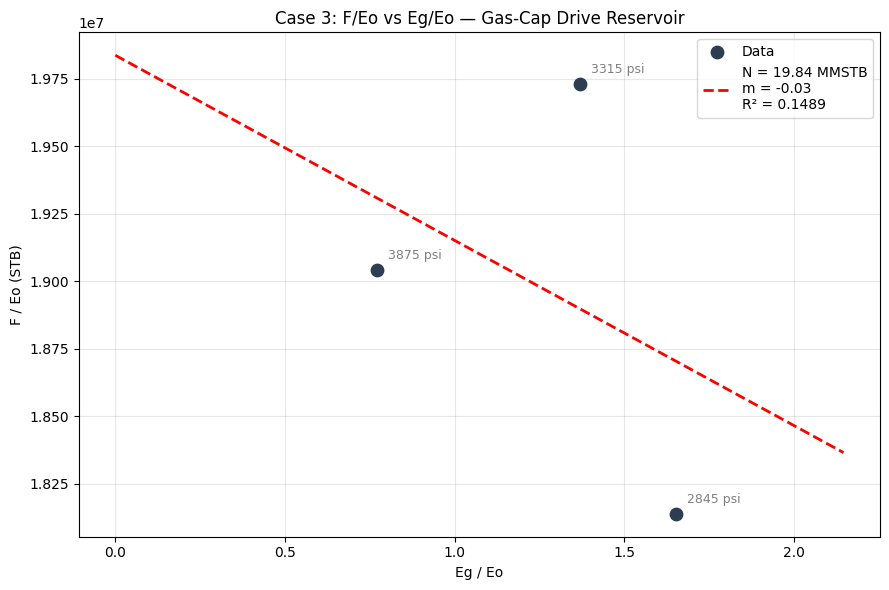

N = 19.84 MMSTB
m = -0.0346
G (initial gas in place) = -1.45 Bscf


In [ ]:
x = data.loc[mask, 'Eg/Eo'].values
y = data.loc[mask, 'F/Eo'].values

slope, intercept, r, _, _ = linregress(x, y)
N_MMSTB = intercept / 1e6
m = slope / intercept

# Initial gas in place: G = m * N * Boi / Bgi
G_Bscf = m * intercept * Bti / Bgi / 1e9

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, c='#2c3e50', s=80, zorder=5, label='Data')

for xi, yi, pi in zip(x, y, data.loc[mask, 'P']):
    ax.annotate(f'{pi:.0f} psi', (xi, yi), textcoords="offset points",
                xytext=(8, 8), fontsize=9, color='gray')

xl = np.linspace(0, x.max() * 1.3, 100)
ax.plot(xl, slope * xl + intercept, 'r--', lw=2,
        label=f'N = {N_MMSTB:.2f} MMSTB\nm = {m:.2f}\nR² = {r**2:.4f}')

ax.set_xlabel('Eg / Eo')
ax.set_ylabel('F / Eo (STB)')
ax.set_title('Case 3: F/Eo vs Eg/Eo — Gas-Cap Drive Reservoir')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"N = {N_MMSTB:.2f} MMSTB")
print(f"m = {m:.4f}")
print(f"G (initial gas in place) = {G_Bscf:.2f} Bscf")

In [ ]:
print("=" * 55)
print("  CASE 3 SUMMARY")
print("  Gas-Cap Drive Reservoir (Tarek Ahmed, Example 11-4)")
print("=" * 55)
print(f"  N (OOIP)             = {N_MMSTB:.2f} MMSTB")
print(f"  m (gas cap ratio)    = {m:.4f}")
print(f"  G (gas in place)     = {G_Bscf:.2f} Bscf")
print(f"  R²                   = {r**2:.4f}")
print()
print("  Note:")
print("  - Only 3 production data points available")
print("  - More data would improve regression reliability")
print("  - Plot: F/Eo vs Eg/Eo gives intercept = N, slope = mN")

  CASE 3 SUMMARY
  Gas-Cap Drive Reservoir (Tarek Ahmed, Example 11-4)
  N (OOIP)             = 19.84 MMSTB
  m (gas cap ratio)    = -0.0346
  G (gas in place)     = -1.45 Bscf
  R²                   = 0.1489

  Note:
  - Only 3 production data points available
  - More data would improve regression reliability
  - Plot: F/Eo vs Eg/Eo gives intercept = N, slope = mN


## Verification with Synthetic Data
The textbook data has known errors. To demonstrate the method works correctly, here's a self-generated consistent dataset for a gas-cap reservoir.

In [ ]:
Rsi_s, Bti_s, Bgi_s = 950, 1.620, 0.00075

synth = pd.DataFrame({
    'P':  [4400, 4000, 3600, 3200, 2800, 2400, 2000],
    'Np': [0, 300, 700, 1150, 1650, 2200, 2800],
    'Gp': [0, 755, 2120, 3900, 5880, 8020, 10120],
    'Bt': [1.620, 1.670, 1.745, 1.845, 1.975, 2.135, 2.330],
    'Bg': [0.00075, 0.00077, 0.00082, 0.00090, 0.00101, 0.00117, 0.00140]
})

m2 = synth['Np'] > 0
Np2 = synth.loc[m2, 'Np'] * 1e3
Gp2 = synth.loc[m2, 'Gp'] * 1e6

synth.loc[m2, 'Rp']    = Gp2.values / Np2.values
synth.loc[m2, 'F']     = Np2.values * synth.loc[m2, 'Bt'].values + (Gp2.values - Np2.values * Rsi_s) * synth.loc[m2, 'Bg'].values
synth.loc[m2, 'Eo']    = synth.loc[m2, 'Bt'] - Bti_s
synth.loc[m2, 'Eg']    = Bti_s * (synth.loc[m2, 'Bg'] / Bgi_s - 1)
synth.loc[m2, 'F/Eo']  = synth.loc[m2, 'F'] / synth.loc[m2, 'Eo']
synth.loc[m2, 'Eg/Eo'] = synth.loc[m2, 'Eg'] / synth.loc[m2, 'Eo']

synth[m2][['P', 'Rp', 'F', 'Eo', 'Eg', 'F/Eo', 'Eg/Eo']].round(4)

,P,Rp,F,Eo,Eg,F/Eo,Eg/Eo
1,4000,2516.6667,862900.0,0.050,0.0432,1.725800e+07,0.8640
2,3600,3028.5714,2414600.0,0.125,0.1512,1.931680e+07,1.2096
3,3200,3391.3043,4648500.0,0.225,0.3240,2.066000e+07,1.4400
4,2800,3563.6364,7614375.0,0.355,0.5616,2.144894e+07,1.5820
5,2400,3645.4545,11635100.0,0.515,0.9072,2.259243e+07,1.7616
6,2000,3614.2857,16968000.0,0.710,1.4040,2.389859e+07,1.9775


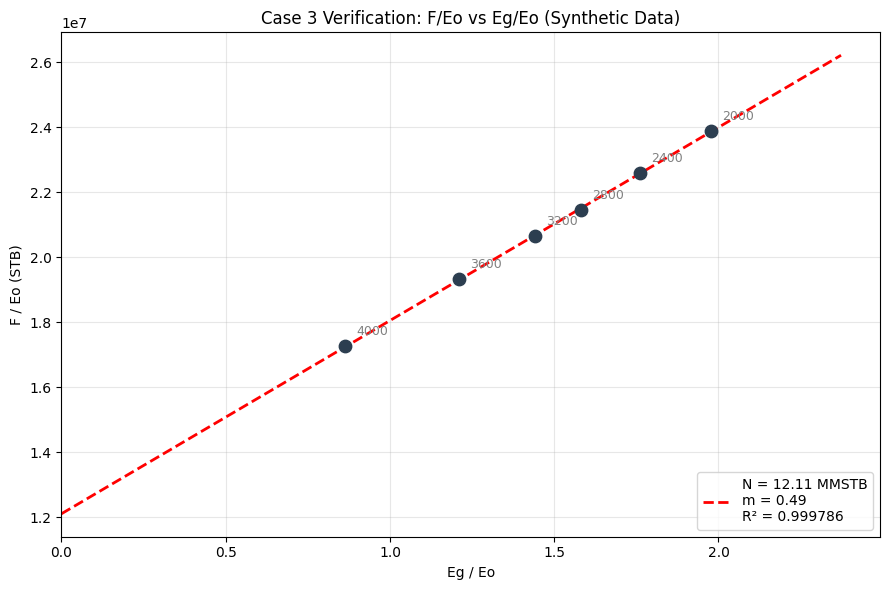

N = 12.11 MMSTB
m = 0.49
G (initial gas in place) = 12.84 Bscf


In [ ]:
xs = synth.loc[m2, 'Eg/Eo'].values
ys = synth.loc[m2, 'F/Eo'].values

sl, ic, r2, _, _ = linregress(xs, ys)
N_s = ic / 1e6
m_s = sl / ic
G_s = m_s * ic * Bti_s / Bgi_s / 1e9

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(xs, ys, c='#2c3e50', s=80, zorder=5)

for xi, yi, pi in zip(xs, ys, synth.loc[m2, 'P']):
    ax.annotate(f'{pi:.0f}', (xi, yi), textcoords="offset points", xytext=(8, 8), fontsize=9, color='gray')

xl = np.linspace(0, xs.max() * 1.2, 100)
ax.plot(xl, sl * xl + ic, 'r--', lw=2, label=f'N = {N_s:.2f} MMSTB\nm = {m_s:.2f}\nR² = {r2**2:.6f}')

ax.set_xlabel('Eg / Eo')
ax.set_ylabel('F / Eo (STB)')
ax.set_title('Case 3 Verification: F/Eo vs Eg/Eo (Synthetic Data)')
ax.legend(loc='lower right')
ax.set_xlim(0); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"N = {N_s:.2f} MMSTB")
print(f"m = {m_s:.2f}")
print(f"G (initial gas in place) = {G_s:.2f} Bscf")

In [ ]:
print("=" * 60)
print("  CASE 3 SUMMARY")
print("  Gas-Cap Drive Reservoir")
print("  MBE: F = N*Eo + N*m*Eg")
print("  Plot: F/Eo vs Eg/Eo → intercept = N, slope = mN")
print("=" * 60)
print()
print("  Textbook Data (Example 11-4):")
print(f"    N = {N_MMSTB:.2f} MMSTB | m = {m:.4f}")
print(f"    R² = {r**2:.4f}")
print(f"    (Only 3 data points + known errors in textbook)")
print()
print("  Synthetic Data (Verification):")
print(f"    N = {N_s:.2f} MMSTB | m = {m_s:.2f}")
print(f"    G = {G_s:.2f} Bscf")
print(f"    R² = {r2**2:.6f}")
print()
print("  Takeaway:")
print("  - With clean data, F/Eo vs Eg/Eo gives both N and m")
print("  - Gas cap expansion (Eg) dominates over oil expansion (Eo)")
print("  - More data points → more reliable regression")

  CASE 3 SUMMARY
  Gas-Cap Drive Reservoir
  MBE: F = N*Eo + N*m*Eg
  Plot: F/Eo vs Eg/Eo → intercept = N, slope = mN

  Textbook Data (Example 11-4):
    N = 19.84 MMSTB | m = -0.0346
    R² = 0.1489
    (Only 3 data points + known errors in textbook)

  Synthetic Data (Verification):
    N = 12.11 MMSTB | m = 0.49
    G = 12.84 Bscf
    R² = 0.999786

  Takeaway:
  - With clean data, F/Eo vs Eg/Eo gives both N and m
  - Gas cap expansion (Eg) dominates over oil expansion (Eo)
  - More data points → more reliable regression
